# This notebook executes test_run.py and test_validate.py interactively 
# and does additional plotting for visual validation

In [1]:
# first execute test_run.py again with detailed code profiling: timing, function calls, etc.
%run -p -s cumulative test_run.py

/Users/viraj/sapphire/sapphire/physical_models/fiducial_model.py:144: RuntimeWarning: invalid value encountered in sqrt
  vturb_cgm = np.sqrt(2*Ekin_cgm / (M_cgm*Msun_to_g)) * 1e-5 # km/s
/Users/viraj/sapphire/sapphire/physical_models/fiducial_model.py:145: RuntimeWarning: divide by zero encountered in double_scalars
  tturb_cgm = (Rturb / (vturb_cgm*1e5*cm_to_kpc)) * s_to_yr*1e-9 # Gyr
/Users/viraj/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: divide by zero encountered in log10
  np.log10(Tval),
/opt/anaconda3/envs/sapphire/lib/python3.10/site-packages/scipy/interpolate/_rgi.py:358: RuntimeWarning: invalid value encountered in add
  values += np.asarray(self.values[edge_indices]) * weight[vslice]
/opt/anaconda3/envs/sapphire/lib/python3.10/site-packages/scipy/interpolate/_rgi.py:357: RuntimeWarning: invalid value encountered in multiply
  weight *= np.where(ei == i, 1 - yi, yi)
/Users/viraj/sapphire/sapphire/physical_models/fiducial_model.py:212: RuntimeWar

>>>>> FINISHED halo=m10q


/Users/viraj/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),


>>>>> FINISHED halo=m11c
>>>>> FINISHED halo=m12m
Finished -- thank you for using sapphire!
 

         7053060 function calls (6863651 primitive calls) in 10.841 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    798/1    0.004    0.000   10.842   10.842 {built-in method builtins.exec}
        1    0.000    0.000   10.842   10.842 interactiveshell.py:2753(safe_execfile)
        1    0.000    0.000   10.841   10.841 py3compat.py:51(execfile)
        1    0.005    0.005   10.840   10.840 test_run.py:1(<module>)
        1    0.001    0.001    9.801    9.801 driver.py:19(run)
        3    0.001    0.000    9.244    3.081 fiducial_model.py:331(integrator)
     7589    0.564    0.000    8.887    0.001 fiducial_model.py:35(evolve_galaxy)
        3    0.004    0.001    5.689    1.896 ivp.py:156(solve_ivp)
      906    0.003    0.000    5.614    0.006 base.py:159(step)
      906    0.042    0.000    5.611    0.006 bdf.py:300(_step_impl)
     4589    0.004    0.000    5.411    0.001 base.py:19(fun_wrapped)
     4589    0.0

In [2]:
# now again execute test_run.py, tell us how long total script takes, AND let us continue to have interactive access to any variables 
%run -t test_run.py

>>>>> FINISHED halo=m10q
>>>>> FINISHED halo=m11c
>>>>> FINISHED halo=m12m
Finished -- thank you for using sapphire!

IPython CPU timings (estimated):
  User   :       8.09 s.
  System :       0.08 s.
Wall time:       8.17 s.


In [3]:
# if this does not raise any assertion error messages, it means the tests were succesful 
%run -t test_validate.py


IPython CPU timings (estimated):
  User   :       0.49 s.
  System :       0.03 s.
Wall time:       0.55 s.


In [5]:
# let's go back and overplot time series of test vs. reference solutions for each of the state variables and their associated derivatives

%matplotlib inline 
import matplotlib.pyplot as plt 
plt.rcParams['figure.dpi'] = 120
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True

In [15]:
### make sure we still have interactive access to the npz_test and npz_ref solution objects defined in test_run.py 
npz_test, npz_ref # if these are not defined, we will get an error, otherwise we are fine

### and also the test_vars list of variables from test_validation.py that we asserted be equal to each other
print(test_vars) 

['cosmic_age', 'redshift', 'M_cgm', 'Mdot_cgm', 'M_ism', 'Mdot_ism', 'M_star', 'Mdot_sfr', 'Eth_cgm', 'Edot_cgm_th', 'Ekin_cgm', 'Edot_cgm_kin', 'MZ_cgm', 'MZdot_cgm', 'MZ_ism', 'MZdot_ism', 'MZ_star', 'MZdot_star']


In [10]:
# choose one of m10q, m11c or m12m and we will create a plot just for that halo alone
halo_name = 'm12m'

# access this halo's test and reference solution from the files already generated by test_run.py and read in by test_validate.py 
halo_test = npz_test[halo_name].item()
halo_ref = npz_ref[halo_name].item()

halo_sols = [halo_test,halo_ref]

(0.001, 1.7573683959750261)

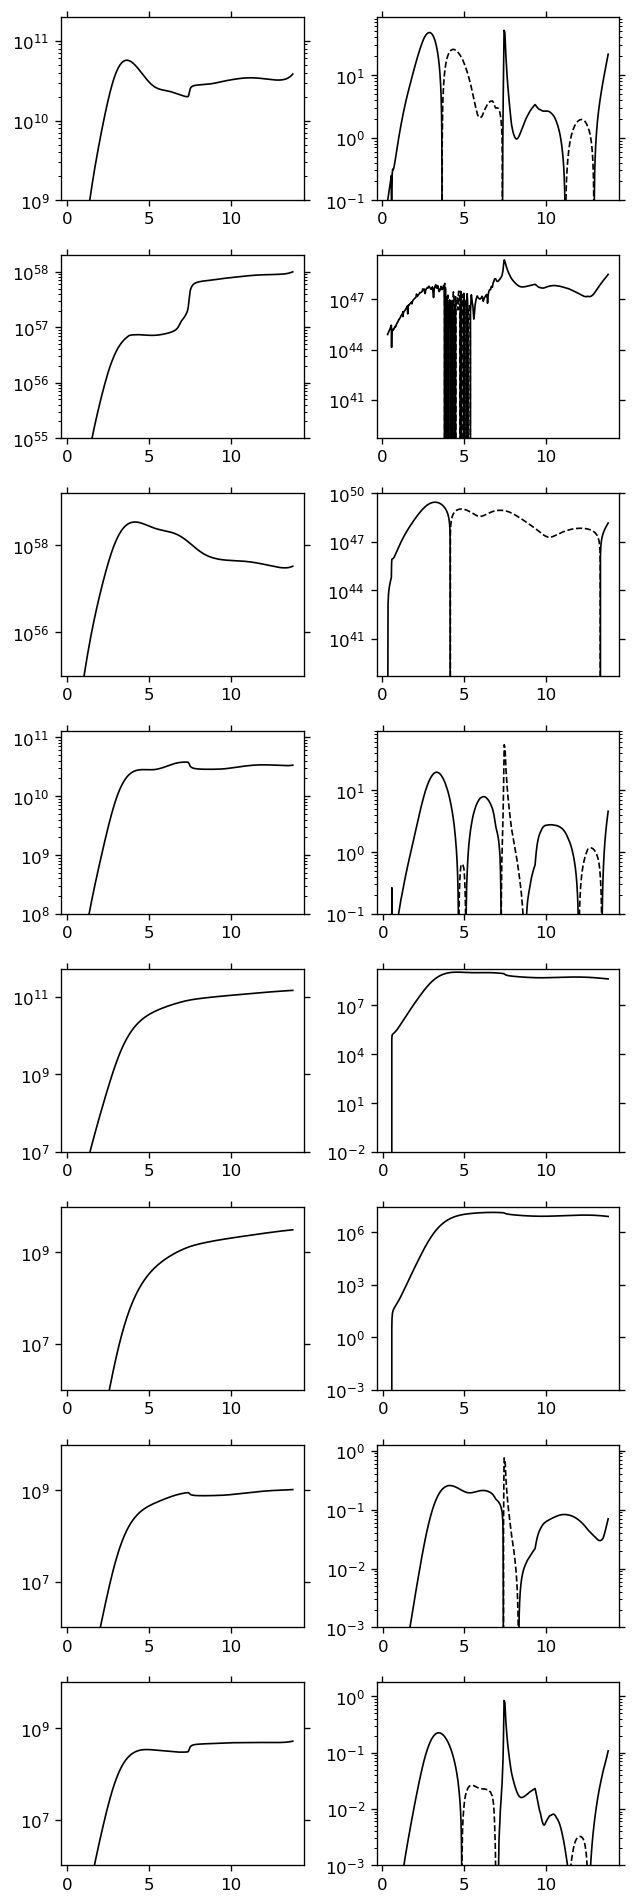

In [16]:
### Set up plot y-axis limits for m10, m11 and m12 halos -- masses, Mdots, energies, Edots
ylims_mcgm = {'m10':(1e7,None),'m11':(1e8,None),'m12':(1e9,None)}
ylims_mism = {'m10':(1e5,None),'m11':(1e7,None),'m12':(1e8,None)}
ylims_mstar = {'m10':(5e4,None),'m11':(1e6,None),'m12':(1e7,None)}
ylims_mdots = {'m10':(1e-3,None),'m11':(1e-2,None),'m12':(1e-1,None)}
ylims_sfr = {'m10':(1e-5,None),'m11':(1e-3,None),'m12':(1e-2,None)}
ylims_ecgm = {'m10':(1e52,None),'m11':(1e54,None),'m12':(1e55,None)}
ylims_edots = {'m10':(1e35,None),'m11':(1e37,5e41),'m12':(5e38,None)}
ylims_zdots = {'m10':(1e-7,None),'m11':(1e-4,None),'m12':(1e-3,None)}
ylims_Zmet = {'m10':(1e-4,1e0),'m11':(1e-4,1e0),'m12':(1e-3,5e0)}
ylims_Mmet = {'m10':(1e2,1e6),'m11':(1e5,1e9),'m12':(1e6,1e10)}

# define constants and units that we may need with astropy 
from astropy import units as u 
s_to_yr = u.s.to('yr') # NOTE: currently sapphire natively outputs Mdot's in Msun/sec, but we will plot Msun/yr

##### Plot state variables and the LHS of their corresponding ODEs vs time
##### dashed lines mean negative derivatives 

fig, axes = plt.subplots(nrows=8,ncols=2,figsize=(6,20))
fig.subplots_adjust(wspace=0.3,hspace=0.3)
allax = np.ravel(axes)

for ax in allax:
    ax.set_yscale('log')

axes[0][0].plot(halo_test['cosmic_age'],halo_test['M_cgm'],'k-',lw=1)
axes[0][0].set_ylim(ylims_mcgm[halo_name[:3]])

axes[0][1].plot(halo_test['cosmic_age'],np.array(halo_test['Mdot_cgm'])/s_to_yr,'k-',lw=1)
axes[0][1].plot(halo_test['cosmic_age'],-np.array(halo_test['Mdot_cgm'])/s_to_yr,'k--',lw=1)
axes[0][1].set_ylim(ylims_mdots[halo_name[:3]])

axes[1][0].plot(halo_test['cosmic_age'],halo_test['Eth_cgm'],'k-',lw=1)
axes[1][0].set_ylim(ylims_ecgm[halo_name[:3]])

axes[1][1].plot(halo_test['cosmic_age'],np.array(halo_test['Edot_cgm_th'])/s_to_yr,'k-',lw=1)
axes[1][1].plot(halo_test['cosmic_age'],-np.array(halo_test['Edot_cgm_th'])/s_to_yr,'k--',lw=1)
axes[1][1].set_ylim(ylims_edots[halo_name[:3]])

axes[2][0].plot(halo_test['cosmic_age'],halo_test['Ekin_cgm'],'k-',lw=1)
axes[2][0].set_ylim(ylims_ecgm[halo_name[:3]])

axes[2][1].plot(halo_test['cosmic_age'],np.array(halo_test['Edot_cgm_kin'])/s_to_yr,'k-',lw=1)
axes[2][1].plot(halo_test['cosmic_age'],-np.array(halo_test['Edot_cgm_kin'])/s_to_yr,'k--',lw=1)
axes[2][1].set_ylim(ylims_edots[halo_name[:3]])

axes[3][0].plot(halo_test['cosmic_age'],halo_test['M_ism'],'k-',lw=1)
axes[3][0].set_ylim(ylims_mism[halo_name[:3]])

axes[3][1].plot(halo_test['cosmic_age'],np.array(halo_test['Mdot_ism'])/s_to_yr,'k-',lw=1)
axes[3][1].plot(halo_test['cosmic_age'],-np.array(halo_test['Mdot_ism'])/s_to_yr,'k--',lw=1)
axes[3][1].set_ylim(ylims_mdots[halo_name[:3]])

axes[4][0].plot(halo_test['cosmic_age'],halo_test['M_star'],'k-',lw=1)
axes[4][0].set_ylim(ylims_mstar[halo_name[:3]])

axes[4][1].plot(halo_test['cosmic_age'],np.array(halo_test['Mdot_sfr'])/s_to_yr,'k-',lw=1)
axes[4][1].plot(halo_test['cosmic_age'],-np.array(halo_test['Mdot_sfr'])/s_to_yr,'k--',lw=1)
axes[4][1].set_ylim(ylims_sfr[halo_name[:3]])

axes[5][0].plot(halo_test['cosmic_age'],halo_test['MZ_star'],'k-',lw=1)
axes[5][0].set_ylim(ylims_Mmet[halo_name[:3]])

axes[5][1].plot(halo_test['cosmic_age'],np.array(halo_test['MZdot_sfr'])/s_to_yr,'k-',lw=1)
axes[5][1].plot(halo_test['cosmic_age'],-np.array(halo_test['MZdot_sfr'])/s_to_yr,'k--',lw=1)
axes[5][1].set_ylim(ylims_zdots[halo_name[:3]])

axes[6][0].plot(halo_test['cosmic_age'],halo_test['MZ_ism'],'k-',lw=1)
axes[6][0].set_ylim(ylims_Mmet[halo_name[:3]])

axes[6][1].plot(halo_test['cosmic_age'],np.array(halo_test['MZdot_ism'])/s_to_yr,'k-',lw=1)
axes[6][1].plot(halo_test['cosmic_age'],-np.array(halo_test['MZdot_ism'])/s_to_yr,'k--',lw=1)
axes[6][1].set_ylim(ylims_zdots[halo_name[:3]])

axes[7][0].plot(halo_test['cosmic_age'],halo_test['MZ_cgm'],'k-',lw=1)
axes[7][0].set_ylim(ylims_Mmet[halo_name[:3]])

axes[7][1].plot(halo_test['cosmic_age'],np.array(halo_test['MZdot_cgm'])/s_to_yr,'k-',lw=1)
axes[7][1].plot(halo_test['cosmic_age'],-np.array(halo_test['MZdot_cgm'])/s_to_yr,'k--',lw=1)
axes[7][1].set_ylim(ylims_zdots[halo_name[:3]])

# You could even just run sapphire interactively in here directly instead of %run magic

In [17]:
import sapphire 

In [ ]:
# define parameters dict as in test_run.py, and then call sapphire.run(parameters) and work with resulting objects interactively 